In [197]:
import numpy as np
import matplotlib.pyplot as plt

# Entropy and the Boltzmann Distribution

Recall _entropy_, the measure of uncertainty about a system given its macroscopic properties (e.g., temperature, pressure, volume).  It measures how probability is spread over the possible _microstates_ of the system.

$$
S = -k\sum_\omega p_\omega \log p_\omega,
$$

where $\omega$ enumerates all possible microstates, and $p_\omega$ is the probability of the system occupying each state.  This is the _statistical mechanics_ definition of entropy.  The _thermodynamic_ definition of entropy $dS = \frac{\delta Q}{T}$ relating the change in entropy in a closed system to incremental and reversable transfer of heat $\delta Q$ into that system of temperature $T$.  Demanding these definitions be equal (and making use of the _fundamental thermodynamic relation_ $dU = T dS - p dV$) leads to the _Boltzmann distribution_ as the solution for describing the probability of a system occupying a particular microstate $\omega$ is

$$
p_\omega = \frac{e^{-E_\omega/kT}}{Z},
$$

where $Z$ the normalization constant resulting from summing the numerator over all possible microstates of the system $\Omega$

$$
Z = \sum_{\omega'\in \Omega}e^{-E_{\omega'}/kT}.
$$

## The Ising Model

We'll use the Boltzmann distribution above to simulate a ferromagnet using a simple, two-dimensional _Ising model_. This model constructs a ferromagnet as a 2-D lattice with $N$ sites, and the spin of each lattice site can be up or down, which we'll representent as $+1$ and $-1$, respectively.

A configuration of the microstate of this system is given by $\omega = \{\omega_1, \omega_2, \dots, \omega_N\}$, where $\omega_i=\pm 1$, meaning there are $|\Omega|=2^N$ possible microstates of the system.

Let's construct a small latice with random initial spins.

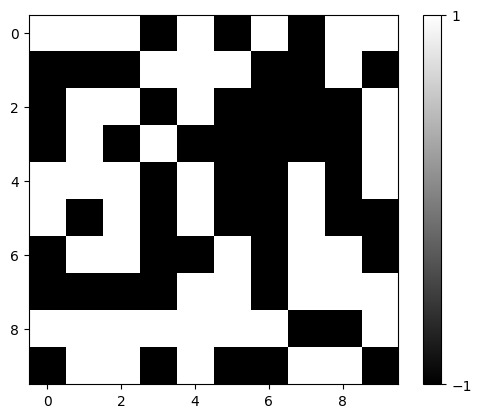

In [198]:
ngrid = 10
N = int(ngrid**2)

state = np.random.choice([-1, 1], size=(ngrid, ngrid))
plt.imshow(state, cmap='gray')
cbar = plt.colorbar()
cbar.set_ticks([-1, 1]);

We'll define the energy of a particular configuration to be

$$
E_\omega = -J\sum_{\left<i,j\right>}\omega_i\omega_j - H\sum_{i=1}^N\omega_i,
$$

where $\left<i,j\right>$ indicates adjacent (i.e., nearest neighbor) sites (vertically or horizontally), $J>0$ drives the strength of coupling between nearest-neighbors, and $H>0$ represents the strength of an external field.

In [199]:
# def energy(state, J=1., H=0.):
#     steps = [1, -1]
#     axes = [0, 1]
#     E = 0
#     for step in steps:
#         for axis in axes:
#             E -= J * np.sum(state * np.roll(state, step, axis=axis))
#     E -= H * np.sum(state)
#     return E

def energy(state, J=1., H=0.):
    E = -J * (
        np.sum(state * np.roll(state, 1, axis=0)) + \
        np.sum(state * np.roll(state, 1, axis=1))
    )
    E += -H * np.sum(state)
    return E

In [200]:
energy(state)

np.float64(8.0)

Now that we can calculate the energy of any particular microstate $\omega$, we can calculate the (relative) probability of occupying that state using the Boltzmann distribution.

In [201]:
def lnBoltz(state, kT=1., J=1., H=0.):
    return -energy(state, J=J, H=H)/kT

I say relative here because we haven't gone through the effort of summing the numerator of the Boltzmann distribution over all possible microstates (i.e., we haven't normalized the distribution).  With this we can calculate the _relative_ probability of the system occupying two different microstates.

In [202]:
def draw_state(N):
    ngrid = int(np.sqrt(N))
    return np.random.choice([-1, 1], size=(ngrid, ngrid))

log(P1/P2) = -4.0
P1/P2 = 0.01831563888873418


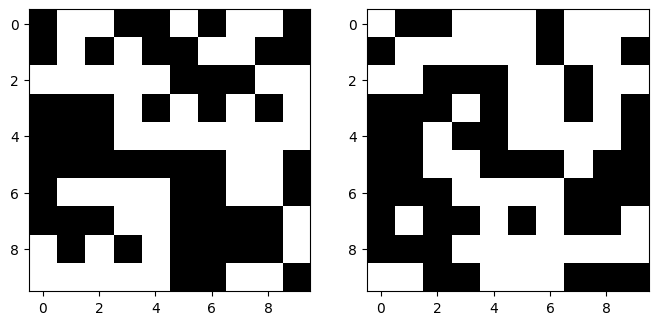

In [203]:
state1 = draw_state(N)
state2 = draw_state(N)

fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].imshow(state1, cmap='gray')
axs[1].imshow(state2, cmap='gray')
log_P_rel = lnBoltz(state1) - lnBoltz(state2)
print("log(P1/P2) = {}".format(log_P_rel))
print("P1/P2 = {}".format(np.exp(log_P_rel)))

## Phase Transition

We can use our model to explore phase transitions, particularly in the _magnetization_. The _magnetization_ of our model for a particular microstate $\omega$ is

$$
M_\omega = \sum_{i=1}^N \omega_i.
$$

To determine the macroscopic magnetization at temperature $T$ we need to calculate the expectation value of this magnetization over possible microstates $\left<M\right>_T$.

$$
\left<M\right>_T = \sum_{\omega \in \Omega} M_\omega p(\omega) = \sum_{\omega \in \Omega} M_\omega \mathrm{Boltz(\omega)}.
$$

Importance sampling to the rescue!  Recall that using some sampling distribution $g(\omega)$ we can estimate such an expectation value using $S$ draws $\omega^1, \dots, \omega^S$ from $g(\omega)$ as

$$
E(h(\omega)) = \frac{\sum_{s=1}^S h(\omega^s) w(\omega^s)}{\sum_{s=1}^S w(\omega^s)}
$$

where

$$
w(\omega^s) = \frac{\mathrm{Boltz}(\omega^s)}{g(\omega^s)}
$$

are the _importance weights_.

Let's use our `draw_state()` function as our sampling distribution.  Since it's uniform over each lattice point's possible spin value $\omega_i$ we don't need to worry about explicitly calculating it for our importance weights (there's just a normalization constant that cancels).  To avoid overflow/underflow we're going to stick to working in the (natural) log as much as possible.

In [204]:
def magnetization(state):
    return np.sum(state)

In [205]:
S = 1000
M_omegas = []
lnws = []
for _ in range(S):
    state = draw_state(N)
    M_omegas.append(magnetization(state))
    lnws.append(lnBoltz(state))

M_omegas = np.array(M_omegas)
lnws = np.array(lnws)

To avoid having to explicitly exponentiate each log term, sum over them, then take the log again (a process very prone to over/underflow, we can make use of some mathematical tricks with `logsumexp()`.

In [206]:
from scipy.special import logsumexp

We can use this fuction to calculate, for example, the log of the sum of the weights in the following way.

In [207]:
log_sum_ws = logsumexp(lnws)
log_sum_ws

np.float64(48.00069643322999)

For the numerator of our importance sampling we need to multiply each weight by the magnetization, which we can do with the `b=` keyword argument.  This should be everything we need.

In [208]:
E_M = np.exp(logsumexp(lnws, b=M_omegas, return_sign=True)[0] - logsumexp(lnws))
E_M

np.float64(5.991631118672161)

...but weight.  We should look at them. 

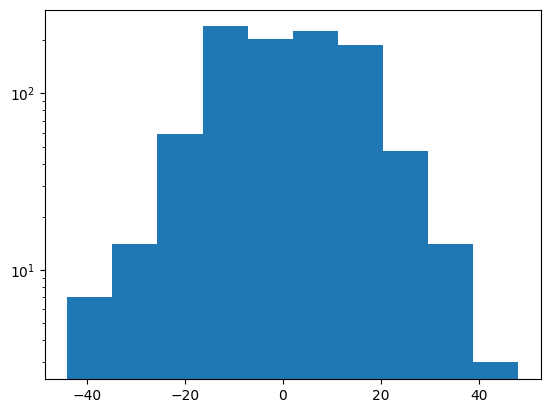

In [209]:
plt.hist(lnws, log=True);

From Chap. 10 of Gelman, we know that we should look at the distribution of weights to get a sense of the accuracy of our estimate.  If there are relatively few extreme weights, then their contributions will dominate our estimate above.  To be more quantitative, we can estimate the effective sample size (ESS).  If this is $\gg1$ we're in good shape, and if it's ${\sim}1$, not so good....

In [210]:
def ess(lnws):
    normalized_lnws = lnws - logsumexp(lnws)
    log_ess = -logsumexp(2*normalized_lnws)
    return np.exp(log_ess)

In [211]:
ess(lnws)

np.float64(1.0013936114136501)

😬

and this is for a small latice!  We must do better!

In [212]:
def proposal(current_state,n=1):
    N = current_state.size
    flip = np.ones(N)
    flip[np.random.choice(N,size=n)] = -1
    return current_state * flip.reshape(current_state.shape)

In [213]:
proposal(state)

array([[ 1.,  1., -1.,  1., -1.,  1.,  1.,  1.,  1., -1.],
       [ 1., -1.,  1., -1., -1., -1., -1., -1., -1., -1.],
       [ 1.,  1.,  1., -1.,  1., -1., -1.,  1., -1., -1.],
       [ 1., -1., -1.,  1.,  1., -1.,  1.,  1., -1.,  1.],
       [ 1., -1.,  1.,  1., -1.,  1., -1.,  1.,  1.,  1.],
       [-1.,  1.,  1.,  1.,  1.,  1.,  1., -1.,  1., -1.],
       [-1., -1., -1.,  1.,  1.,  1., -1., -1., -1., -1.],
       [-1.,  1., -1.,  1., -1.,  1.,  1.,  1.,  1., -1.],
       [ 1., -1.,  1., -1., -1., -1., -1., -1.,  1.,  1.],
       [ 1.,  1.,  1.,  1., -1.,  1., -1., -1., -1.,  1.]])

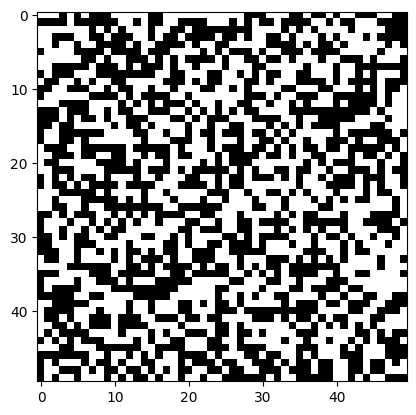

In [214]:
kT = 50.
J = 1.
H = 0.

energy_fun = lambda state: energy(state,J=J,H=H)
lnBoltz_fun = lambda state: lnBoltz(state, kT=kT,J=J,H=H)

ngrid = 50
N = int(ngrid**2)
initial_state = draw_state(N)
plt.imshow(initial_state,cmap = 'gray')

In [215]:
#actual mcmc
#no better way than for loop

current_state = initial_state
current_lnBoltz = lnBoltz_fun(current_state)

Nsteps = 100000
energies = []
magnetizations = []

for _ in range(Nsteps):
    energies.append(energy_fun(current_state))
    magnetizations.append(magnetization(current_state))

    #proposed location
    proposed_state = proposal(current_state, n=1)
    proposed_lnBoltz = lnBoltz(proposed_state)

    #calculate acceptance probability
    ln_prob = proposed_lnBoltz - current_lnBoltz
    #decide to accept 
    #if ratio is less than some drawn number accept it
    if np.log(np.random.rand())< ln_prob:
        #update current location
        current_state = proposed_state
        current_lnBoltz = proposed_lnBoltz

Text(0.5, 0, 'step')

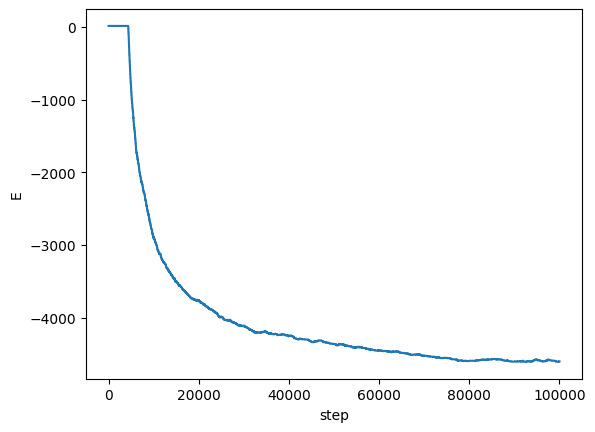

In [217]:
plt.plot(energies)
plt.ylabel('E')
plt.xlabel('step')
#bad initial draws push initial large shifts


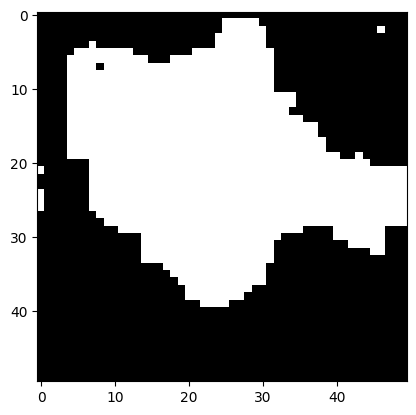

In [218]:
plt.imshow(current_state,cmap = 'gray')

Text(0, 0.5, 'M')

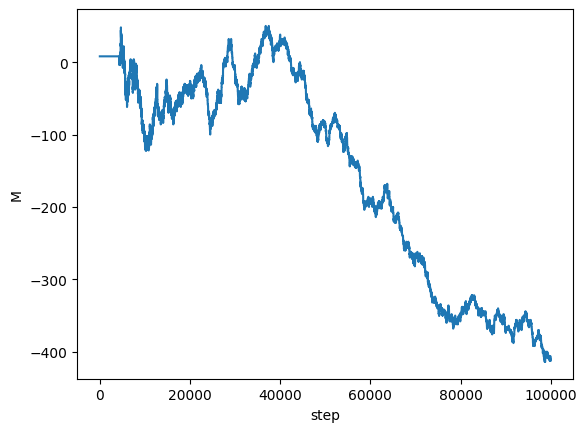

In [219]:
plt.plot(magnetizations)
plt.xlabel('step')
plt.ylabel('M')

In [220]:
%look at individual vairables and check how they change over hte course of the mcmc
%behavior from healthy mcmc doesnt have general trends (bulk motion around paramter space)
%look for correlation want to pick out points that are NOT correlated so find ones that are not near by to each other 
%can try to minimize correlation
%want goldie lox region of steps 

UsageError: Line magic function `%look` not found.
